In [1]:
import sys

sys.path.append("..")


from src.plotting.feature_plotting import plot_graph
import matplotlib.pyplot as plt
import numpy as np
import torch

DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
PLOTS_DIR = "../plots"
from src.data_preparation import load_numpy_files

signal_prefix = f"{DATA_DIR}/sig"
background_prefix = f"{DATA_DIR}/bg"
signal_only_prefix = f"{DATA_DIR}/sig_only"


In [2]:
pixel_data = np.load(f"{signal_prefix}_pixel_spacetime.npy")
pixel_labels = np.load(f"{signal_prefix}_pixel_track_labels.npy")
mppc_data = np.load(f"{signal_prefix}_mppc_spacetime.npy")
mppc_labels = np.load(f"{signal_prefix}_mppc_track_labels.npy")

In [3]:
pixel_track_time_range = []
for i in range(pixel_labels.shape[0]):
    track_ids = np.unique(pixel_labels[i, 0])
    track_ids = track_ids[track_ids != -1]
    for track_id in track_ids:
        track_mask = pixel_labels[i,:,0] == track_id
        track_times = pixel_data[i, track_mask, -1]
        if track_times.size > 0:
            pixel_track_time_range.append(track_times.max() - track_times.min())

In [4]:
mppc_track_time_range = []
for i in range(mppc_labels.shape[0]):
    track_ids = np.unique(mppc_labels[i, 0])
    track_ids = track_ids[track_ids != -1]
    for track_id in track_ids:
        track_mask = mppc_labels[i,:,0] == track_id
        track_times = mppc_data[i, track_mask, -1]
        if track_times.size > 0:
            mppc_track_time_range.append(track_times.max() - track_times.min())

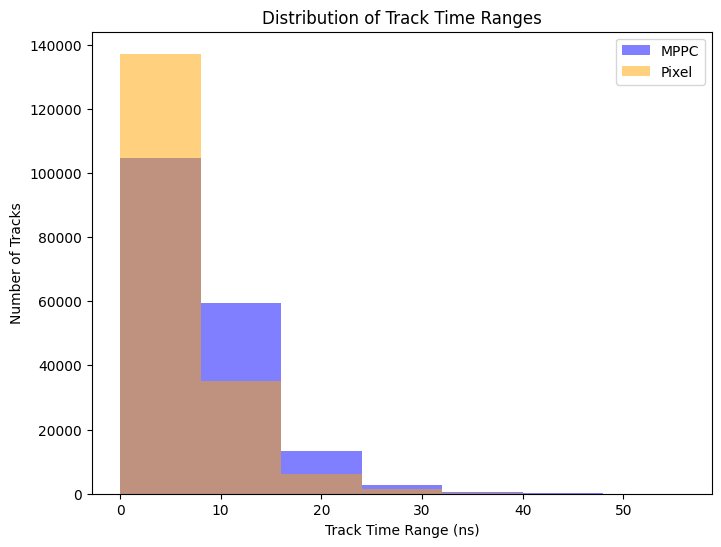

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(mppc_track_time_range, bins=7, alpha=0.5, label="MPPC", color="blue", range=(0, 7*8))
ax.hist(pixel_track_time_range, bins=7, alpha=0.5, label="Pixel", color="orange", range=(0, 7*8))
ax.set_xlabel("Track Time Range (ns)")
ax.set_ylabel("Number of Tracks")
ax.set_title("Distribution of Track Time Ranges")
ax.legend()
plt.savefig(f"{PLOTS_DIR}/track_time_range_comparison.png")

In [3]:
import src.torch.pre_processing.graph_batching as graph_batching
from importlib import reload

reload(graph_batching)



<module 'src.torch.pre_processing.graph_batching' from '/Users/simi/mu3e_trigger/notebooks_feature_plotting/../src/torch/pre_processing/graph_batching.py'>

In [4]:
layer_separated_hetero_graph_dataset = graph_batching.create_dataset(
    signal_prefix, has_layer_feature=True, sequence_mode=False, n_events=1000, split=(1,), type="layer_separated"
)

In [ ]:

def plot_detector(ax):
    layer_1_circle = plt.Circle((0, 0), 23, color="red", fill=False, linestyle="dashed", alpha = 0.5)
    layer_2_circle = plt.Circle((0, 0), 29.5, color="red", fill=False, linestyle="dashed", alpha = 0.5)
    scifi_layer_circle = plt.Circle((0, 0), 61, color="blue", fill=False, linewidth=10, alpha = 0.5)
    layer_3_circle = plt.Circle((0, 0), 72, color="red", fill=False, linestyle="dashed", alpha = 0.5)
    layer_4_circle = plt.Circle((0, 0), 86, color="red", fill=False, linestyle="dashed", alpha = 0.5)


    ax.set_xlim(-90, 90)
    ax.set_ylim(-90, 90)
    ax.add_patch(layer_1_circle)
    ax.add_patch(layer_2_circle)
    ax.add_patch(scifi_layer_circle)
    ax.add_patch(layer_3_circle)
    ax.add_patch(layer_4_circle)
    ax.scatter(0, 0, c="black", s=50, label="Target position")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    # hide spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

def plot_graph_to_axis(ax, graph, no_edges = False):
    mppc_nodes = graph["mppc"].x
    pixel_nodes = np.concatenate(
        [
            graph["layer_1"].x,
            graph["layer_2"].x,
            graph["layer_3"].x,
            graph["layer_4"].x,
        ],
        axis=0,
    )
    ax.scatter(mppc_nodes[:, 0], mppc_nodes[:, 1], c="blue", s=20, label="MPPC hits")
    ax.scatter(pixel_nodes[:, 0], pixel_nodes[:, 1], c="red", s=20, label="Pixel hits")
    if no_edges:
        return
    layer_1_to_layer_2_edges = graph["layer_1", "to", "layer_2"]
    for edge_idx in range(layer_1_to_layer_2_edges.edge_index.shape[1]):
        if layer_1_to_layer_2_edges.edge_labels[edge_idx] != 1:
            color = "orange"
        else:
            color = "green"

        edge = layer_1_to_layer_2_edges.edge_index[:, edge_idx]
        ax.plot(
            [
                graph["layer_1"].x[edge[0], 0],
                graph["layer_2"].x[edge[1], 0],
            ],
            [
                graph["layer_1"].x[edge[0], 1],
                graph["layer_2"].x[edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )
    layer_2_to_mppc_edges = graph["layer_2", "to", "mppc"]
    for edge_idx in range(layer_2_to_mppc_edges.edge_index.shape[1]):
        if layer_2_to_mppc_edges.edge_labels[edge_idx] != 1:
            color="orange"
        else:
            color="green"
        edge = layer_2_to_mppc_edges.edge_index[:, edge_idx]
        ax.plot(
            [
                graph["layer_2"].x[edge[0], 0],
                graph["mppc"].x[edge[1], 0],
            ],
            [
                graph["layer_2"].x[edge[0], 1],
                graph["mppc"].x[edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )
    mppc_to_layer_3_edges = graph["mppc", "to", "layer_3"]
    for edge_idx in range(mppc_to_layer_3_edges.edge_index.shape[1]):
        if mppc_to_layer_3_edges.edge_labels[edge_idx] != 1:
            color="orange"
        else:
            color="green"
        edge = mppc_to_layer_3_edges.edge_index[:, edge_idx]
        ax.plot(
            [
                graph["mppc"].x[edge[0], 0],
                graph["layer_3"].x[edge[1], 0],
            ],
            [
                graph["mppc"].x[edge[0], 1],
                graph["layer_3"].x[edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )
    layer_3_to_layer_4_edges = graph["layer_3", "to", "layer_4"]
    for edge_idx in range(layer_3_to_layer_4_edges.edge_index.shape[1]):
        if layer_3_to_layer_4_edges.edge_labels[edge_idx] != 1:
            color="orange"
        else:
            color="green"
        edge = layer_3_to_layer_4_edges.edge_index[:, edge_idx]
        ax.plot(
            [
                graph["layer_3"].x[edge[0], 0],
                graph["layer_4"].x[edge[1], 0],
            ],
            [
                graph["layer_3"].x[edge[0], 1],
                graph["layer_4"].x[edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )

In [6]:
layer_separated_hetero_graph_dataset

DetectorDataset(4437)

In [7]:
layer_separated_hetero_graph_dataset[0]

HeteroData(
  layer_1={
    x=[1, 3],
    track_truth=[1, 5],
  },
  layer_2={
    x=[1, 3],
    track_truth=[1, 5],
  },
  layer_3={
    x=[2, 3],
    track_truth=[2, 5],
  },
  layer_4={
    x=[2, 3],
    track_truth=[2, 5],
  },
  mppc={
    x=[5, 4],
    track_truth=[5, 5],
  },
  (layer_1, to, layer_2)={
    edge_index=[2, 1],
    edge_labels=[1],
  },
  (layer_2, to, layer_1)={
    edge_index=[2, 1],
    edge_labels=[1],
  },
  (layer_2, to, mppc)={
    edge_index=[2, 5],
    edge_labels=[5],
  },
  (mppc, to, layer_2)={
    edge_index=[2, 5],
    edge_labels=[5],
  },
  (mppc, to, mppc)={
    edge_index=[2, 2],
    edge_labels=[2],
  },
  (mppc, to, layer_3)={
    edge_index=[2, 10],
    edge_labels=[10],
  },
  (layer_3, to, mppc)={
    edge_index=[2, 10],
    edge_labels=[10],
  },
  (layer_3, to, layer_4)={
    edge_index=[2, 4],
    edge_labels=[4],
  },
  (layer_4, to, layer_3)={
    edge_index=[2, 4],
    edge_labels=[4],
  },
  (layer_4, to, layer_4)={
    edge_index=[2, 

In [ ]:
pixel_data[1][:,-1] // 8, mppc_data[1][:,-1]

(array([  48.,   48.,    0.,   16.,   16.,    0.,    0.,    8.,   48.,
          48.,    8.,   24.,   48.,    0.,   48.,   48.,   16.,   16.,
           0.,    0.,    8.,   48.,   48.,    8.,   24.,   32.,   32.,
          32.,   32.,   32.,   24.,    0.,   32.,   32.,   32.,   48.,
          32.,   32.,   16.,   32.,    0.,    0.,    8.,    0.,    8.,
          24.,   24.,   48.,   16.,    0.,    8.,   24.,    8.,   32.,
          48.,   48.,   32.,   32.,   32.,   32.,   32.,   32.,   32.,
          32.,   32.,   16.,   24.,   32.,   32.,   32.,   32.,   32.,
          32.,   16.,   32.,   32.,   32.,   24.,   32.,   32.,   32.,
          32.,   24.,    0.,   48.,   32.,   32.,   16.,   32.,    0.,
           0.,    8.,    8.,   24.,   24.,   48.,   16.,   48.,   48.,
           0.,    8.,   24.,    8.,   32.,   48.,   48.,   32.,   32.,
          32.,   32.,   32.,   32.,   32.,   32.,   32., -999., -999.,
        -999., -999., -999., -999., -999., -999., -999., -999., -999.,
      

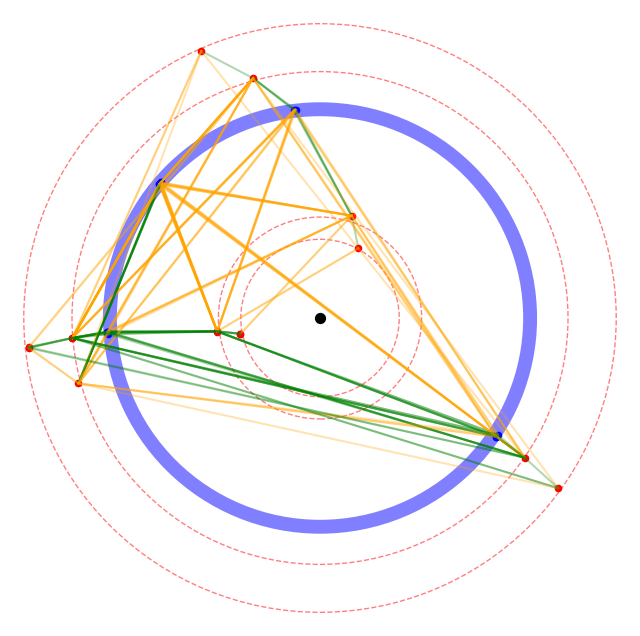

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
plot_detector(ax)
#plot_graph_to_axis(ax, layer_separated_hetero_graph_dataset[0], no_edges=False)
plot_graph_to_axis(ax, layer_separated_hetero_graph_dataset[6], no_edges=False)

In [10]:
layer_separated_hetero_graph_dataset[0]["mppc"].x

tensor([[  54.9054,  -29.3380, -150.1250,    7.1500],
        [  54.9701,  -29.0965, -150.1250,    7.1000],
        [ -46.3114,   39.4293,  150.1250,    7.9500],
        [ -46.4881,   39.2525,  150.1250,    7.6000],
        [  54.9767,  -29.0721,  137.6250,    6.7500]])

In [11]:
layer_separated_hetero_graph_dataset[1]["mppc"].x

tensor([[ -46.1336,   39.6071, -137.6250,   10.5500],
        [ -46.3103,   39.4303, -137.6250,    9.5000],
        [ -46.4871,   39.2535, -137.6250,    8.5500],
        [ -46.6639,   39.0768, -137.6250,   10.1000],
        [ -35.3559,  -50.3848, -150.1250,   13.6000],
        [ -35.1791,  -50.5615, -150.1250,   13.6000],
        [  55.0995,  -28.6135, -150.1250,   13.7000],
        [ -46.6649,   39.0757,  150.1250,    8.1000],
        [ -35.5270,  -50.2136,  137.6250,   13.3000],
        [ -35.3503,  -50.3904,  137.6250,   13.6500],
        [ -35.1735,  -50.5672,  137.6250,   14.0500],
        [ -34.9967,  -50.7439,  137.6250,   14.4000],
        [  54.9120,  -29.3136,  137.6250,   13.0000],
        [  55.0414,  -28.8306,  137.6250,   10.7500],
        [  55.1061,  -28.5891,  137.6250,   13.7500]])

In [12]:
layer_separated_hetero_graph_dataset[1]["mppc"].track_truth

tensor([[ 22.1369, -18.0760,  -6.1254,  29.2330, -11.0000],
        [ 22.1369, -18.0760,  -6.1254,  29.2330, -11.0000],
        [ 22.1369, -18.0760,  -6.1254,  29.2330, -11.0000],
        [ 22.1369, -18.0760,  -6.1254,  29.2330, -11.0000],
        [-28.8472, -29.3388, -12.6977,  43.0630, -11.0000],
        [-28.8472, -29.3388, -12.6977,  43.0630, -11.0000],
        [ 22.1369, -18.0760,  -6.1254,  29.2330, -11.0000],
        [ 22.1369, -18.0760,  -6.1254,  29.2330, -11.0000],
        [-28.8472, -29.3388, -12.6977,  43.0630, -11.0000],
        [-28.8472, -29.3388, -12.6977,  43.0630, -11.0000],
        [-28.8472, -29.3388, -12.6977,  43.0630, -11.0000],
        [-28.8472, -29.3388, -12.6977,  43.0630, -11.0000],
        [ 22.1369, -18.0760,  -6.1254,  29.2330, -11.0000],
        [ 22.1369, -18.0760,  -6.1254,  29.2330, -11.0000],
        [ 22.1369, -18.0760,  -6.1254,  29.2330, -11.0000]])

(array([379581., 374593., 374843., 374685., 369405., 367607., 366399.,
        362939., 360731., 359724., 358038., 355522., 356296., 356016.,
        354846., 352071., 353515., 353460., 353514., 353404., 353203.,
        352668., 351604., 351189., 349310., 347391., 348340., 346293.,
        348423., 349957., 351322., 349734., 348232., 346784., 347446.,
        346353., 348170., 348879., 350517., 350158., 350834., 350663.,
        348963., 347709., 348109., 348490., 349015., 348977., 348099.,
        348430., 348985., 348980., 350605., 351920., 353462., 353819.,
        354768., 356132., 360393., 363527., 365022., 372364., 379129.,
        384996.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
        52., 53., 54., 55., 56., 57., 58., 59., 60

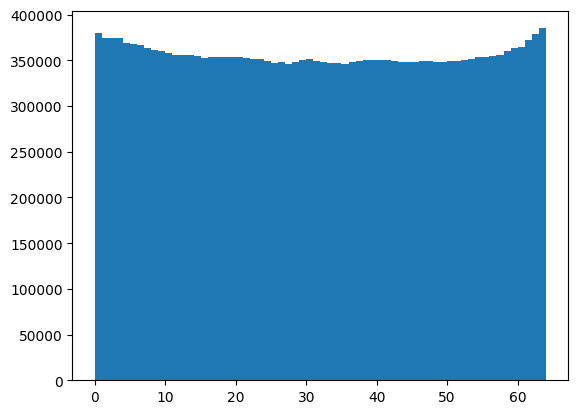

In [19]:
plt.hist(mppc_data[:,:,-1][mppc_data[:,:,-1] != -999], range = (0, 64), bins = 64)

(array([1581298., 1554256., 1549215., 1546298., 1555999., 1553239.,
        1584953., 1690854.]),
 array([ 0.,  8., 16., 24., 32., 40., 48., 56., 64.]),
 <BarContainer object of 8 artists>)

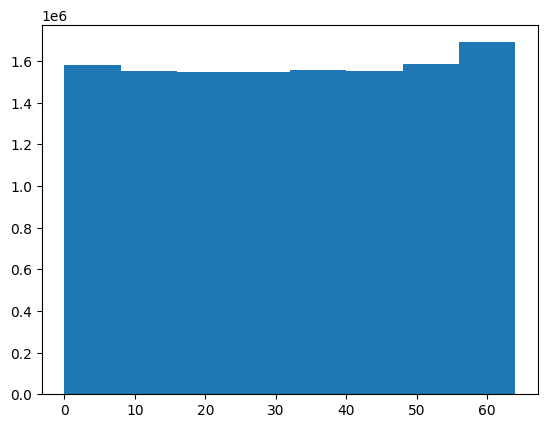

In [17]:
plt.hist(pixel_data[:,:,-1][pixel_data[:,:,-1] != -999], range = (0, 64), bins = 8)